In [26]:
%cd /content/drive/MyDrive/2026/EMI/rotoscope

/content/drive/MyDrive/2026/EMI/rotoscope


In [27]:
# After trying to create a latent walk from the following references
# 1. Outpainting I - Controlnet version. Url: https://huggingface.co/blog/OzzyGT/outpainting-controlnet
# 2. A walk through latent space with Stable Diffusion. Url: https://keras.io/examples/generative/random_walks_with_stable_diffusion/

# I created a 'latent' walk based on code from ChatGPT
# 3. ChatGPT log Url: https://chatgpt.com/share/6a31c842-dec4-83eb-9b89-150aed089c89
# 4: ChatGPT https://chatgpt.com/share/6a17139b-3688-83eb-be26-68790e67b334
# 5: ChatGPT https://chatgpt.com/share/6a3d9f71-7e0c-83eb-bc91-a08caace2a14
# 6: ChatGPT https://chatgpt.com/share/6a3bfef4-4a14-83eb-8549-5f12bcc1baca
# 7: Using frames for animation based on EMI Week 6 Homework and ChatGPT

In [28]:
# Import necessary libraries
# 1:
import random
from io import BytesIO

import requests
import torch
from PIL import Image

from diffusers import (
    AutoPipelineForImage2Image,
    ControlNetModel,
    DPMSolverMultistepScheduler,
    StableDiffusionXLControlNetPipeline,
)
from diffusers.image_processor import IPAdapterMaskProcessor
from diffusers.utils import load_image, logging
from diffusers.utils.logging import set_verbosity

In [29]:
# 1: Controlnet Model
### 1: "controlnet for SDXL trained for inpainting by destitech"
controlnet = ControlNetModel.from_pretrained(
    "destitech/controlnet-inpaint-dreamer-sdxl", torch_dtype=torch.float16, variant="fp16"
)

# 1:
pipeline = StableDiffusionXLControlNetPipeline.from_pretrained(
    "RunDiffusion/Juggernaut-XL-v9",
    torch_dtype=torch.float16,
    variant="fp16",
    controlnet=controlnet,
).to("cuda")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

In [30]:
## 1: "[Controlnet Model is] easy to use, you just need to paint white the parts you want to replace"
### 1: "what I'm going to do is paint white the transparent part of the image.""

# 1: To paint white the alpha channel of an image I use this code"
### Fetches an image with an edited transparent area illustrating what needs to be inpainted

# 4: Previously used code from a different project
# change to local folder name
input_folder = '/content/drive/MyDrive/2026/EMI/rotoscope'

pipeline.scheduler = DPMSolverMultistepScheduler.from_config(pipeline.scheduler.config) # 1
pipeline.scheduler.config.use_karras_sigmas = True # 1

In [31]:
# 1 adding ip adapter
pipeline.load_ip_adapter(
    "h94/IP-Adapter",
    subfolder="sdxl_models",
    weight_name="ip-adapter-plus_sdxl_vit-h.safetensors",
    image_encoder_folder="models/image_encoder",
)
pipeline.set_ip_adapter_scale(0.5) # higher for stronger background mask

Loading weights:   0%|          | 0/520 [00:00<?, ?it/s]

In [32]:
mask = Image.open(f'{input_folder}/masks/mask-25-June.png') # 1. Background mask, change to local file path for mask
ip_mask = mask # 1

processor = IPAdapterMaskProcessor() # 1
ip_masks = processor.preprocess(ip_mask, height=1024, width=1024) # 1

In [43]:
prompt = "Pond water" # 1 Prompt for background mask
negative_prompt = ""

def lerp(a, b, t):
    return (1 - t) * a + t * b #5: Lerp Function for latent walk

# 5: https://chatgpt.com/share/6a3d6202-4ab8-83eb-8f06-6f7f535e958f
# 5: Generate the starting noise yourself
latent_shape = (
    1,
    pipeline.unet.config.in_channels,
    1024 // 8,
    1024 // 8,
) # 5

seed1 = 1234 # 5
seed2 = 5678 # 5

noise1 = torch.randn(
    latent_shape,
    generator=torch.Generator("cuda").manual_seed(seed1),
    device="cuda",
    dtype=torch.float16,
) # 5

noise2 = torch.randn(
    latent_shape,
    generator=torch.Generator("cuda").manual_seed(seed2),
    device="cuda",
    dtype=torch.float16,
) # 5


frames = []

seed = random.randint(0, 2**32 - 1)
generator = torch.Generator(device="cpu").manual_seed(seed)

num_frames = 60 # 5

promptCounter = 0

for i in range(6):
    # if i % 3 == 0:
    #   if promptCounter == len(prompts) - 1:
    #     promptCounter == 0
    #   else:
    #     promptCounter += 1

    # prompt = prompts[promptCounter]


    t = i / (num_frames - 1) # 5 how quickly the latent noise transitions
    # 5: Now Interpolate
    latents = lerp(noise1, noise2, t)

    # 1: To paint white the alpha channel of an image I use this code"
    ### 1: Fetches an image with an edited transparent area illustrating what needs to be inpainted
    num_str = str(i + 1).zfill(1) # 1, modified
    response = Image.open(f'{input_folder}/frames/frame-{num_str}.png') # modified from 1. Change to match own frames file path
    control_image = response # 1
    new_controlnet_image = Image.new("RGBA", control_image.size, "WHITE") # 1
    new_controlnet_image.alpha_composite(control_image) # 1


    # changed to just pipeline with help from ChatGPT ref 5
    image = pipeline(
        prompt=prompt,
        negative_prompt=negative_prompt,
        height=1024,
        width=1024,
        image=new_controlnet_image,
        controlnet_conditioning_scale=0.8,
        control_guidance_end=0.8,
        guidance_scale=5.0, # higher for stronger prompt reference
        num_inference_steps=25,
        # generator=generator, # removed after ChatGPT ref 5 advice
        latents=latents,
        strength=0.9, # higher = model more freedom to incorporate the reference image
        ip_adapter_image=ip_mask, # originally got confused by ref 1's code. This needs to be the background mask
        cross_attention_kwargs={"ip_adapter_masks": ip_masks},
    ).images[0]

    frames.append(image) # Append current image generation to frames list # 6

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

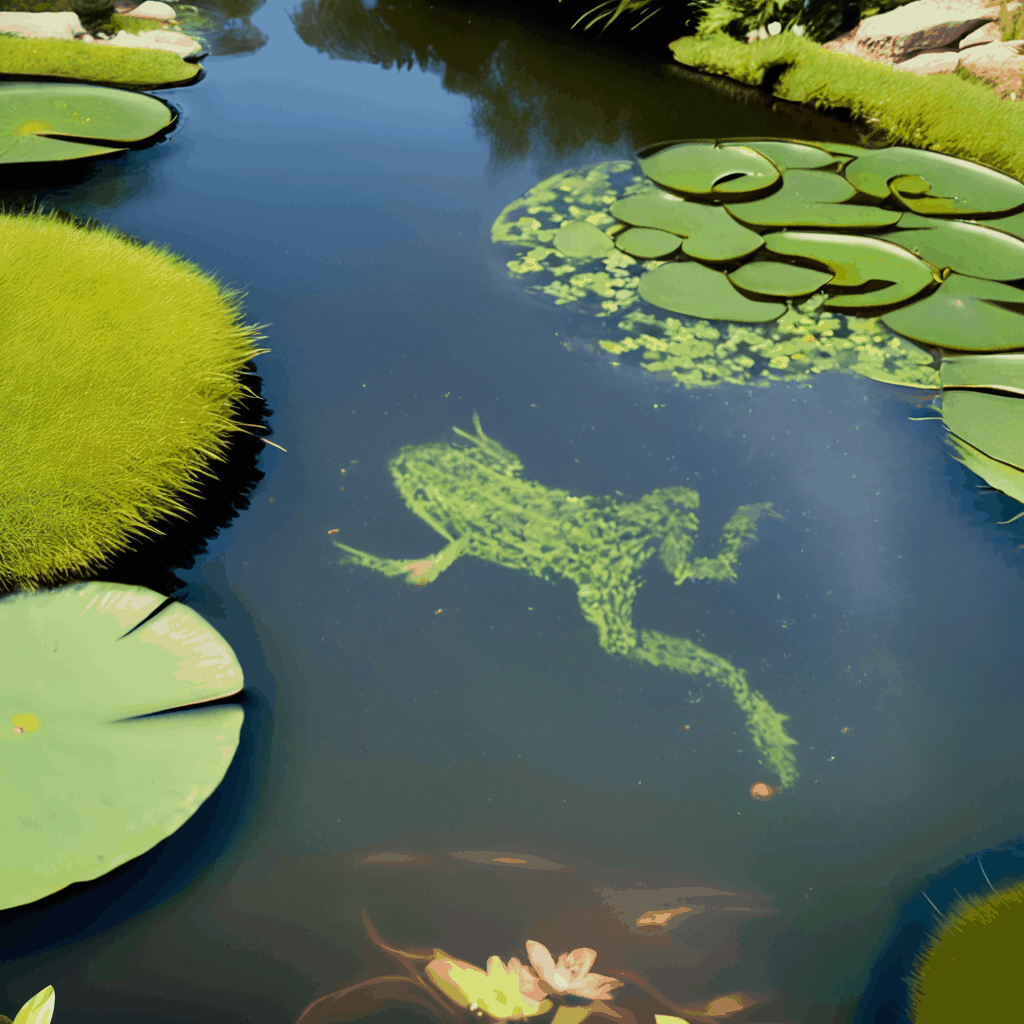

In [44]:

# Generate Image, based off ChatGPT Code
from PIL import Image

gifName = "7-frog-Thu-25-June.gif" # Modified for easier file naming between generations

frames[0].save(
    gifName,
    save_all=True,
    append_images=frames[1:],
    duration=250,
    loop=0,
)

from IPython.display import Image as IImage
IImage(gifName, width=300)